<a href="https://colab.research.google.com/github/ShaojieDong503/HAD5016-Datathon-4/blob/main/datathon_4_lstm_undersample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Physics lab report - PRA 0006 Group C.docx',
 'Physics lab report - PRA 0006 Group C.gdoc',
 'Class 5 PSYA02.gdoc',
 'Class 8 p1.docx',
 'Class 8 p2.docx',
 'FinalReview1.pdf',
 'FinalReview2.pdf',
 'Class81.pdf',
 'Class8part2.pdf',
 'IMG20191217191322.jpg',
 'image1.jpg',
 'image2.jpg',
 '待办事项列表.gsheet',
 '无标题电子表格.gsheet',
 'Academic History.pdf',
 'Dong-Shaojie-cv-Sept-2021.pdf',
 'Dong-Shaojie- transcript-Sept-2021.pdf',
 'Assignment 1.docx',
 'a2.gdoc',
 'Dong_Shaojie_cv_Nov_2021.pdf',
 'video3892838179.mp4',
 '无标题文档 (3).gdoc',
 '无标题文档 (2).gdoc',
 '无标题文档 (1).gdoc',
 '无标题文档.gdoc',
 'KylianMbappe.mp4',
 'Cover Letter .pdf',
 'Colab Notebooks',
 'resume final.pdf',
 'CavePainting.jpg',
 'Untitled project.gscript',
 'q4.py',
 'SDDsubset.zip',
 'DBIsubset.zip',
 'CSC420_2023_Tutorial_06.ipynb',
 'train',
 'CSC420_2023_Tutorial_05.ipynb',
 'dog-breed-classifier-final.ipynb',
 'SDD_tasks.ipynb',
 'SDD_DBI_Classification.ipynb',
 'DBI_SDD_tasks.ipynb',
 'CSC420_Tutorial_8.5_B.Taati.ipyn

In [ ]:
IN_DIR = '/content/drive/My Drive/ML_Datathon/datathon4.csv'
in_file = "datathon4.csv"

In [ ]:
IN_DIR = '/content/drive/My Drive/ML_Datathon/Datathon_4'
in_file = "Datathon #4 - mhealth Dataset - HAD7001.csv"

In [ ]:
import pandas as pd

In [ ]:
#df = pd.read_csv('/content/drive/MyDrive/datathon4.csv')
#df.head()

In [ ]:
import os
import re
import io
import numpy as np
import pandas as pd

in_path = os.path.join(IN_DIR, in_file)
df = pd.read_csv(in_path)
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.18490,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.01030,0.034483,0,subject1
1,2.38760,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.01030,0.034483,0,subject1
2,2.40860,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.01030,0.034483,0,subject1
3,2.18140,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.00820,0.025862,0,subject1
4,2.41730,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999994,0.75593,-8.9661,4.38220,-0.465680,-0.54597,0.61690,-6.6138,-2.5801,6.985600,-0.69804,0.48049,0.616380,2,subject9
999995,0.76348,-8.8288,4.25370,-0.465680,-0.54597,0.61690,-6.4246,-2.5633,6.673900,-0.69804,0.48049,0.616380,2,subject9
999996,0.76376,-8.9685,4.14250,-0.484230,-0.54221,0.63065,-6.8242,-2.5435,6.654100,-0.71373,0.46817,0.601290,2,subject9
999997,0.80362,-8.8894,4.12610,-0.484230,-0.54221,0.63065,-6.6379,-2.5223,6.769700,-0.71373,0.46817,0.601290,2,subject9


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# -------------------------
# Basic inspection
# -------------------------
print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isna().sum())



Shape: (999999, 14)
      alx     aly      alz       glx      gly      glz     arx     ary  \
0  2.1849 -9.6967  0.63077  0.103900 -0.84053 -0.68762 -8.6499 -4.5781   
1  2.3876 -9.5080  0.68389  0.085343 -0.83865 -0.68369 -8.6275 -4.3198   
2  2.4086 -9.5674  0.68113  0.085343 -0.83865 -0.68369 -8.5055 -4.2772   
3  2.1814 -9.4301  0.55031  0.085343 -0.83865 -0.68369 -8.6279 -4.3163   
4  2.4173 -9.3889  0.71098  0.085343 -0.83865 -0.68369 -8.7008 -4.1459   

        arz      grx     gry       grz  Activity   subject  
0  0.187760 -0.44902 -1.0103  0.034483         0  subject1  
1  0.023595 -0.44902 -1.0103  0.034483         0  subject1  
2  0.275720 -0.44902 -1.0103  0.034483         0  subject1  
3  0.367520 -0.45686 -1.0082  0.025862         0  subject1  
4  0.407290 -0.45686 -1.0082  0.025862         0  subject1  
alx         float64
aly         float64
alz         float64
glx         float64
gly         float64
glz         float64
arx         float64
ary         float64
arz      

In [ ]:
# =========================================================
# 0. IMPORTS
# =========================================================
import numpy as np
import pandas as pd
from collections import Counter

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib.pyplot as plt

In [ ]:
# =========================================================
# 1. CONFIG
# =========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

feature_cols = [
    "alx", "aly", "alz",
    "glx", "gly", "glz",
    "arx", "ary", "arz",
    "grx", "gry", "grz"
]

target_col = "Activity"
subject_col = "subject"

WINDOW_SIZE = 128
STEP_SIZE = 64
MIN_MAJORITY_FRAC = 0.8

val_subjects = ["subject7"]
test_subjects = ["subject8", "subject9"]

BATCH_SIZE = 128
NUM_EPOCHS = 20
PATIENCE = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0

Using device: cuda


In [ ]:
# =========================================================
# 3. CLEAN DATA
# =========================================================
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
df.columns = [str(c).strip() for c in df.columns]

required_cols = feature_cols + [target_col, subject_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df[subject_col] = df[subject_col].astype(str).str.strip()

df = df.dropna(subset=feature_cols + [target_col, subject_col]).copy()
df = df.drop_duplicates().copy()

df = df.reset_index(drop=False).rename(columns={"index": "orig_idx"})
df = df.sort_values([subject_col, "orig_idx"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("\nRows per subject:")
print(df[subject_col].value_counts().sort_index())

print("\nRaw class counts:")
print(df[target_col].value_counts().sort_index())

Cleaned shape: (999999, 15)

Rows per subject:
subject
subject1    161280
subject2    130561
subject3    122112
subject4    116736
subject5    119808
subject6     98304
subject7    104448
subject8    129024
subject9     17726
Name: count, dtype: int64

Raw class counts:
Activity
0     720946
1      27648
2      25406
3      24576
4      24576
5      24576
6      22990
7      23809
8      23501
9      24576
10     24576
11     24576
12      8243
Name: count, dtype: int64


In [ ]:
# =========================================================
# 4. SUBJECT-WISE SPLIT
# =========================================================
all_subjects = sorted(df[subject_col].unique())
train_subjects = [s for s in all_subjects if s not in val_subjects + test_subjects]

train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df   = df[df[subject_col].isin(val_subjects)].copy()
test_df  = df[df[subject_col].isin(test_subjects)].copy()





print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

print("Train rows:", train_df.shape)
print("Val rows:", val_df.shape)
print("Test rows:", test_df.shape)

Train subjects: ['subject1', 'subject2', 'subject3', 'subject4', 'subject5', 'subject6']
Val subjects: ['subject7']
Test subjects: ['subject8', 'subject9']
Train rows: (748801, 15)
Val rows: (104448, 15)
Test rows: (146750, 15)


In [ ]:
# =========================================================
# 5. WINDOWING
#    - majority label
#    - drop ambiguous windows
#    - no normalization
# =========================================================
def create_windows_majority(
    df_in,
    feature_cols,
    target_col="Activity",
    subject_col="subject",
    window_size=128,
    step_size=64,
    min_majority_frac=0.8
):
    X_list = []
    y_list = []
    meta_list = []

    for subj, g in df_in.groupby(subject_col, sort=False):
        g = g.sort_values("orig_idx").reset_index(drop=True)

        X_subj = g[feature_cols].to_numpy(dtype=np.float32)
        y_subj = g[target_col].to_numpy(dtype=np.int64)

        n = len(g)
        if n < window_size:
            continue

        for start in range(0, n - window_size + 1, step_size):
            end = start + window_size
            x_win = X_subj[start:end]
            y_win = y_subj[start:end]

            vals, counts = np.unique(y_win, return_counts=True)
            maj_idx = np.argmax(counts)
            maj_class = vals[maj_idx]
            maj_frac = counts[maj_idx] / window_size

            if maj_frac < min_majority_frac:
                continue

            X_list.append(x_win)
            y_list.append(maj_class)
            meta_list.append({
                "subject": subj,
                "start_idx": start,
                "end_idx": end - 1,
                "majority_frac": maj_frac,
                "label": maj_class
            })

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int64)
    meta = pd.DataFrame(meta_list)
    return X, y, meta

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

In [ ]:
# =========================================================
# 6. BUILD TRAIN / VAL / TEST WINDOWS
# =========================================================
X_train, y_train, meta_train = create_windows_majority(
    train_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

X_val, y_val, meta_val = create_windows_majority(
    val_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

X_test, y_test, meta_test = create_windows_majority(
    test_df,
    feature_cols=feature_cols,
    target_col=target_col,
    subject_col=subject_col,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    min_majority_frac=MIN_MAJORITY_FRAC
)

print("Train windows:", X_train.shape, Counter(y_train))
print("Val windows:  ", X_val.shape, Counter(y_val))
print("Test windows: ", X_test.shape, Counter(y_test))

Train windows: (11539, 128, 12) Counter({np.int64(0): 8372, np.int64(1): 282, np.int64(2): 282, np.int64(3): 282, np.int64(4): 282, np.int64(9): 282, np.int64(10): 282, np.int64(11): 282, np.int64(5): 282, np.int64(7): 276, np.int64(8): 276, np.int64(6): 269, np.int64(12): 90})
Val windows:   (1595, 128, 12) Counter({np.int64(0): 1078, np.int64(1): 47, np.int64(2): 47, np.int64(3): 47, np.int64(4): 47, np.int64(6): 47, np.int64(9): 47, np.int64(10): 47, np.int64(11): 47, np.int64(8): 43, np.int64(7): 42, np.int64(5): 41, np.int64(12): 15})
Test windows:  (2260, 128, 12) Counter({np.int64(0): 1694, np.int64(1): 94, np.int64(2): 58, np.int64(3): 47, np.int64(4): 47, np.int64(9): 47, np.int64(10): 47, np.int64(11): 47, np.int64(5): 46, np.int64(7): 46, np.int64(8): 39, np.int64(6): 33, np.int64(12): 15})


In [ ]:
# =========================================================
# 5. OPTIONAL DOWNSAMPLE OF ACTIVITY 0 ONLY
# =========================================================
def downsample_activity_zero(X, y, keep_ratio=1.0, random_state=42):
    """
    keep_ratio = 1.0 -> keep all class 0 rows
    keep_ratio = 0.5 -> keep 50% of class 0 rows
    keep_ratio = 0.3 -> keep 30% of class 0 rows
    """
    rng = np.random.default_rng(random_state)

    idx_zero = np.where(y == 0)[0]
    idx_other = np.where(y != 0)[0]

    keep_n_zero = int(len(idx_zero) * keep_ratio)
    keep_n_zero = max(keep_n_zero, 1)

    chosen_zero = rng.choice(idx_zero, size=keep_n_zero, replace=False)

    keep_idx = np.concatenate([chosen_zero, idx_other])
    rng.shuffle(keep_idx)

    return X[keep_idx], y[keep_idx]

# default: no resampling
USE_DOWNSAMPLE_ZERO = True
ZERO_KEEP_RATIO = 0.5   # only used if USE_DOWNSAMPLE_ZERO = True

if USE_DOWNSAMPLE_ZERO:
    X_train_nn, y_train_nn = downsample_activity_zero(
        X_train, y_train,
        keep_ratio=ZERO_KEEP_RATIO,
        random_state=SEED
    )
else:
    X_train_nn, y_train_nn = X_train.copy(), y_train.copy()

print("Final NN train counts:", Counter(y_train_nn))

Final NN train counts: Counter({np.int64(0): 4186, np.int64(1): 282, np.int64(10): 282, np.int64(3): 282, np.int64(4): 282, np.int64(11): 282, np.int64(2): 282, np.int64(9): 282, np.int64(5): 282, np.int64(8): 276, np.int64(7): 276, np.int64(6): 269, np.int64(12): 90})


In [ ]:
# =========================================================
# 7. DATASET
# =========================================================
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SequenceDataset(X_train_nn, y_train_nn)
val_dataset   = SequenceDataset(X_val, y_val)
test_dataset  = SequenceDataset(X_test, y_test)

In [ ]:

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
from collections import Counter
import torch

class_counts = Counter(y_train)
print("Class counts:", class_counts)

num_samples = len(y_train)
num_classes = len(class_counts)

weights = []
for i in range(num_classes):
    weights.append(num_samples / (num_classes * class_counts[i]))

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class counts: Counter({np.int64(0): 8372, np.int64(1): 282, np.int64(2): 282, np.int64(3): 282, np.int64(4): 282, np.int64(9): 282, np.int64(10): 282, np.int64(11): 282, np.int64(5): 282, np.int64(7): 276, np.int64(8): 276, np.int64(6): 269, np.int64(12): 90})
Class weights: tensor([0.1060, 3.1476, 3.1476, 3.1476, 3.1476, 3.1476, 3.2997, 3.2160, 3.2160,
        3.1476, 3.1476, 3.1476, 9.8624], device='cuda:0')


In [ ]:
# =========================================================
# 9. NORMAL LSTM
# =========================================================
num_classes = len(np.unique(y_train))
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

print("num_classes:", num_classes)
print("timesteps:", timesteps)
print("n_features:", n_features)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, num_classes=3, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0  # no dropout inside LSTM for 1 layer
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (B, T, F)
        out, (hn, cn) = self.lstm(x)
        last_hidden = hn[-1]   # (B, hidden_size)
        logits = self.fc(last_hidden)
        return logits

model = LSTMClassifier(
    input_size=n_features,
    hidden_size=64,
    num_layers=1,
    num_classes=num_classes,
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

num_classes: 13
timesteps: 128
n_features: 12


In [ ]:
# =========================================================
# 10. TRAIN / EVAL FUNCTIONS
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [ ]:
# =========================================================
# 11. TRAIN LOOP
# =========================================================
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20, patience=5):
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [ ]:
# =========================================================
# 12. TRAIN
# =========================================================
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

Epoch 01/20 | Train Loss: 2.3144 | Train Acc: 0.1530 | Val Loss: 2.2526 | Val Acc: 0.1072
Epoch 02/20 | Train Loss: 1.3146 | Train Acc: 0.2534 | Val Loss: 2.0490 | Val Acc: 0.1248
Epoch 03/20 | Train Loss: 0.9841 | Train Acc: 0.2935 | Val Loss: 1.9082 | Val Acc: 0.1655
Epoch 04/20 | Train Loss: 0.9833 | Train Acc: 0.3001 | Val Loss: 1.6480 | Val Acc: 0.1486
Epoch 05/20 | Train Loss: 0.8208 | Train Acc: 0.3218 | Val Loss: 2.0735 | Val Acc: 0.1210
Epoch 06/20 | Train Loss: 0.7320 | Train Acc: 0.3367 | Val Loss: 2.1795 | Val Acc: 0.1386
Epoch 07/20 | Train Loss: 0.6513 | Train Acc: 0.3581 | Val Loss: 1.7568 | Val Acc: 0.2056
Epoch 08/20 | Train Loss: 0.8406 | Train Acc: 0.3356 | Val Loss: 2.1963 | Val Acc: 0.1605
Epoch 09/20 | Train Loss: 0.8458 | Train Acc: 0.3180 | Val Loss: 1.9097 | Val Acc: 0.1693
Early stopping triggered.


In [ ]:
# =========================================================
# 13. FINAL EVALUATION
# =========================================================
train_loss, train_acc, y_train_true, y_train_pred = evaluate(model, train_loader, criterion, device)
val_loss, val_acc, y_val_true, y_val_pred = evaluate(model, val_loader, criterion, device)
test_loss, test_acc, y_test_true, y_test_pred = evaluate(model, test_loader, criterion, device)

print("\nFinal metrics")
print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")


Final metrics
Train Loss: 0.6895 | Train Acc: 0.3540
Val   Loss: 1.9097 | Val   Acc: 0.1693
Test  Loss: 2.5002 | Test  Acc: 0.1097


In [ ]:
# =========================================================
# 14. REPORTS
# =========================================================
print("\nTEST CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, digits=4))

print("TEST CONFUSION MATRIX")
print(confusion_matrix(y_test_true, y_test_pred))


TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.4537    0.0289    0.0544      1694
           1     0.0000    0.0000    0.0000        94
           2     0.1069    0.6379    0.1832        58
           3     0.5875    1.0000    0.7402        47
           4     0.0066    0.0426    0.0115        47
           5     0.0000    0.0000    0.0000        46
           6     0.0000    0.0000    0.0000        33
           7     0.0000    0.0000    0.0000        46
           8     0.0000    0.0000    0.0000        39
           9     0.1919    0.4043    0.2603        47
          10     0.3383    0.9574    0.5000        47
          11     0.4865    0.7660    0.5950        47
          12     0.1287    0.8667    0.2241        15

    accuracy                         0.1097      2260
   macro avg     0.1769    0.3618    0.1976      2260
weighted avg     0.3772    0.1097    0.0908      2260

TEST CONFUSION MATRIX
[[ 49 145 257  33 233 171 172

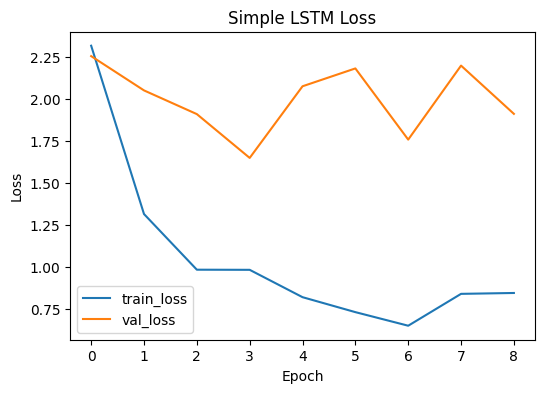

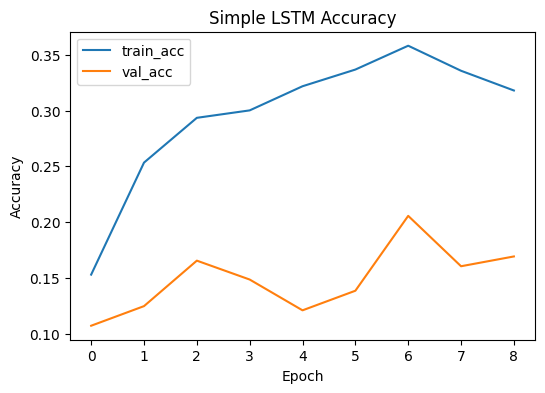

In [ ]:
# =========================================================
# 15. PLOT HISTORY
# =========================================================
def plot_history(history, title="LSTM"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train_acc")
    plt.plot(history["val_acc"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history, title="Simple LSTM")

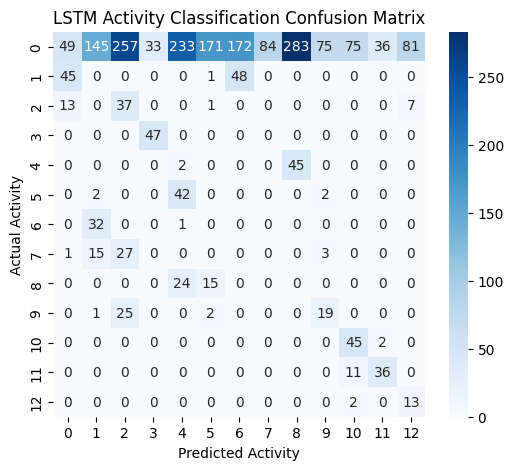

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("LSTM Activity Classification Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")

plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Macro F1:", f1_score(y_test_true, y_test_pred, average="macro"))
print("Weighted F1:", f1_score(y_test_true, y_test_pred, average="weighted"))

print("Macro Precision:", precision_score(y_test_true, y_test_pred, average="macro"))
print("Macro Recall:", recall_score(y_test_true, y_test_pred, average="macro"))

Macro F1: 0.1975864891467337
Weighted F1: 0.09076914150805404
Macro Precision: 0.17694054236918672
Macro Recall: 0.3618258528416603
